# TASK 4: Email Spam Detection with Machine Learning

## Objective

Build a Natural Language Processing (NLP) binary classifier that distinguishes spam messages from legitimate (ham) messages.

### Technologies Used
- Python
- Pandas
- Scikit-learn
- NLTK
- Matplotlib
- Seaborn
- Jupyter Notebook

### Dataset
SMS Spam Collection Dataset

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [6]:
df = pd.read_csv(
    "SMSSpamCollection",
    sep="\t",
    header=None,
    names=["label", "message"],
    encoding="utf-8"
)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (5572, 2)


In [7]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [8]:
print("Dataset Shape:", df.shape)

print("\nDataset Information:")
df.info()

Dataset Shape: (5572, 2)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [9]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 403


In [10]:
print("Spam and Ham Distribution:")
print(df["label"].value_counts())

Spam and Ham Distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


In [11]:
class_percentage = df["label"].value_counts(normalize=True) * 100

print("Class Distribution Percentage:")
print(class_percentage.round(2))

Class Distribution Percentage:
label
ham     86.59
spam    13.41
Name: proportion, dtype: float64


In [12]:
distribution = pd.DataFrame({
    "Count": df["label"].value_counts(),
    "Percentage": df["label"].value_counts(normalize=True) * 100
})

distribution.round(2)

,Count,Percentage
label,,
ham,4825,86.59
spam,747,13.41


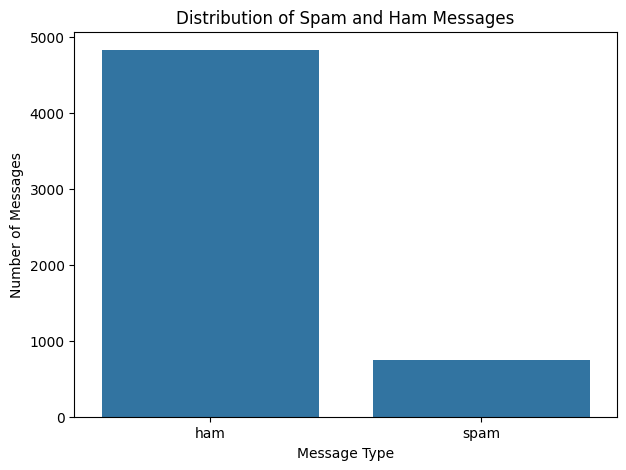

In [13]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="label"
)

plt.title("Distribution of Spam and Ham Messages")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")

plt.show()

In [14]:
df["label_encoded"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

df[["label", "label_encoded"]].head(10)

,label,label_encoded
0,ham,0
1,ham,0
2,spam,1
3,ham,0
4,ham,0
5,spam,1
6,ham,0
7,ham,0
8,spam,1
9,spam,1


In [15]:
!pip install nltk

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
import nltk

nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sweta\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [17]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

print("Number of English stopwords:", len(stop_words))

Number of English stopwords: 198


In [18]:
def preprocess_text(text):
    
    # Convert text to lowercase
    text = text.lower()
    
    # Remove punctuation and special characters
    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)
    
    # Split text into words
    words = text.split()
    
    # Remove stopwords
    words = [
        word for word in words
        if word not in stop_words
    ]
    
    # Join words back together
    text = " ".join(words)
    
    return text

In [19]:
df["clean_message"] = df["message"].apply(preprocess_text)

df[["message", "clean_message"]].head(10)

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry 2 wkly comp win fa cup final tkts 2...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though
5,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey darling 3 weeks word back id like ...
6,Even my brother is not like to speak with me. ...,even brother like speak treat like aids patent
7,As per your request 'Melle Melle (Oru Minnamin...,per request melle melle oru minnaminunginte nu...
8,WINNER!! As a valued network customer you have...,winner valued network customer selected receiv...
9,Had your mobile 11 months or more? U R entitle...,mobile 11 months u r entitled update latest co...


In [20]:
df["message_length"] = df["message"].apply(len)

df[["message", "message_length"]].head()

,message,message_length
0,"Go until jurong point, crazy.. Available only ...",111
1,Ok lar... Joking wif u oni...,29
2,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,U dun say so early hor... U c already then say...,49
4,"Nah I don't think he goes to usf, he lives aro...",61


## TF-IDF Feature Extraction

TF-IDF stands for Term Frequency-Inverse Document Frequency.

TF-IDF converts text messages into numerical features that machine learning algorithms can understand.

Term Frequency (TF) measures how frequently a word appears in a particular message.

Inverse Document Frequency (IDF) reduces the importance of words that appear frequently across many messages.

Therefore, TF-IDF gives higher importance to words that are more distinctive to a particular message and lower importance to common words.

In [21]:
X = df["clean_message"]
y = df["label_encoded"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5572,)
y shape: (5572,)


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4457
Testing samples: 1115


In [23]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2)
)

In [24]:
X_train_tfidf = tfidf.fit_transform(X_train)

In [25]:
X_test_tfidf = tfidf.transform(X_test)

In [26]:
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (4457, 34564)
Testing TF-IDF shape: (1115, 34564)


#Classifier 1: Multinomial Naive Bayes

In [29]:
nb_model = MultinomialNB()

nb_model.fit(
    X_train_tfidf,
    y_train
)

nb_pred = nb_model.predict(X_test_tfidf)

print("Multinomial Naive Bayes completed!")

Multinomial Naive Bayes completed!


In [30]:
nb_accuracy = accuracy_score(y_test, nb_pred)
nb_precision = precision_score(y_test, nb_pred)
nb_recall = recall_score(y_test, nb_pred)
nb_f1 = f1_score(y_test, nb_pred)

print("Multinomial Naive Bayes")
print("-----------------------")
print("Accuracy :", round(nb_accuracy, 4))
print("Precision:", round(nb_precision, 4))
print("Recall   :", round(nb_recall, 4))
print("F1-Score :", round(nb_f1, 4))

Multinomial Naive Bayes
-----------------------
Accuracy : 0.9578
Precision: 1.0
Recall   : 0.6846
F1-Score : 0.8127


In [31]:
print(classification_report(
    y_test,
    nb_pred,
    target_names=["Ham", "Spam"]
))

              precision    recall  f1-score   support

         Ham       0.95      1.00      0.98       966
        Spam       1.00      0.68      0.81       149

    accuracy                           0.96      1115
   macro avg       0.98      0.84      0.89      1115
weighted avg       0.96      0.96      0.95      1115



#Classifier 2: Logistic Regression

In [32]:
lr_model = LogisticRegression(
    max_iter=1000
)

lr_model.fit(
    X_train_tfidf,
    y_train
)

lr_pred = lr_model.predict(X_test_tfidf)

print("Logistic Regression completed!")

Logistic Regression completed!


In [33]:
lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred)
lr_recall = recall_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)

print("Logistic Regression")
print("-------------------")
print("Accuracy :", round(lr_accuracy, 4))
print("Precision:", round(lr_precision, 4))
print("Recall   :", round(lr_recall, 4))
print("F1-Score :", round(lr_f1, 4))

Logistic Regression
-------------------
Accuracy : 0.9534
Precision: 1.0
Recall   : 0.651
F1-Score : 0.7886


In [34]:
print(classification_report(
    y_test,
    lr_pred,
    target_names=["Ham", "Spam"]
))

              precision    recall  f1-score   support

         Ham       0.95      1.00      0.97       966
        Spam       1.00      0.65      0.79       149

    accuracy                           0.95      1115
   macro avg       0.97      0.83      0.88      1115
weighted avg       0.96      0.95      0.95      1115



#Compare Both Models

In [35]:
results = pd.DataFrame({
    "Model": [
        "Multinomial Naive Bayes",
        "Logistic Regression"
    ],
    "Accuracy": [
        nb_accuracy,
        lr_accuracy
    ],
    "Precision": [
        nb_precision,
        lr_precision
    ],
    "Recall": [
        nb_recall,
        lr_recall
    ],
    "F1-Score": [
        nb_f1,
        lr_f1
    ]
})

results.round(4)

,Model,Accuracy,Precision,Recall,F1-Score
0,Multinomial Naive Bayes,0.9578,1.0,0.6846,0.8127
1,Logistic Regression,0.9534,1.0,0.6510,0.7886


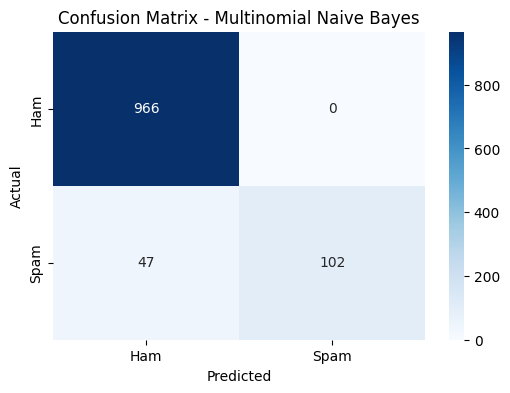

In [36]:
cm_nb = confusion_matrix(y_test, nb_pred)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("Confusion Matrix - Multinomial Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

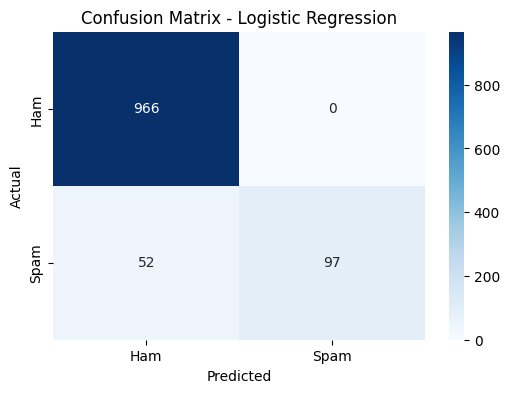

In [37]:
cm_lr = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Why is Recall Particularly Important for Spam Detection?

Recall measures the proportion of actual spam messages that are correctly identified by the model.

Recall is particularly important for spam detection because a false negative occurs when an actual spam message is classified as a legitimate (ham) message. This means that the spam message may reach the user's inbox.

A higher recall means that the model successfully detects a larger proportion of actual spam messages.

However, precision is also important. A false positive occurs when a legitimate message is incorrectly classified as spam. This could cause an important legitimate message to be missed.

Therefore, a spam detection system should consider both precision and recall. The F1-score is also useful because it provides a balance between precision and recall.

In [38]:
!pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [39]:
from wordcloud import WordCloud

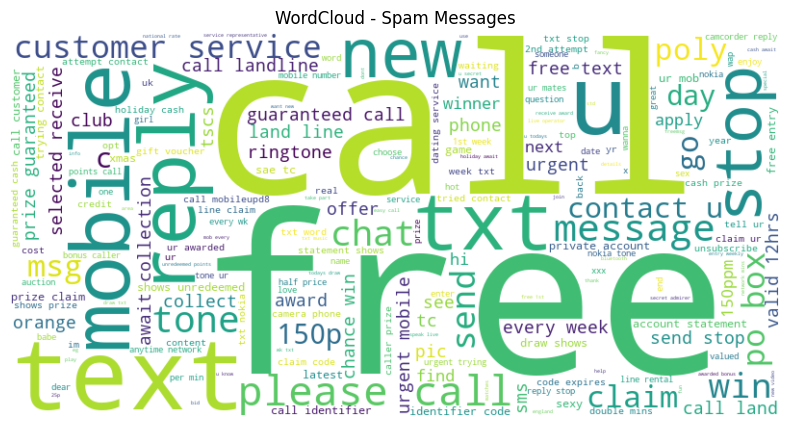

In [40]:
spam_text = " ".join(
    df[df["label"] == "spam"]["clean_message"]
)

spam_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(spam_text)

plt.figure(figsize=(10, 5))

plt.imshow(
    spam_wordcloud,
    interpolation="bilinear"
)

plt.axis("off")
plt.title("WordCloud - Spam Messages")

plt.show()

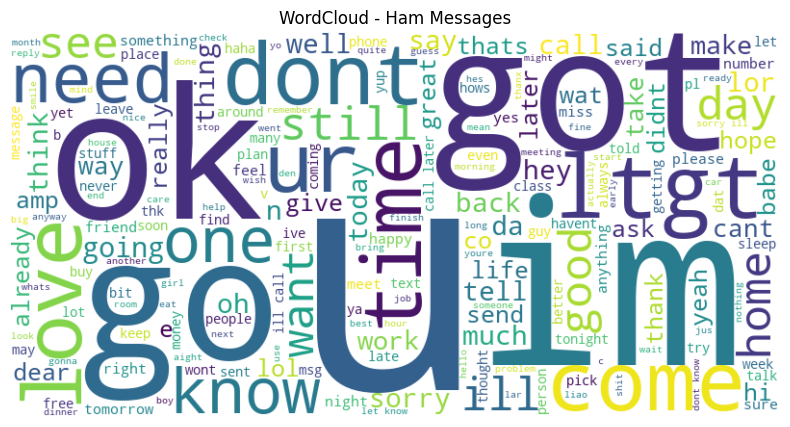

In [41]:
ham_text = " ".join(
    df[df["label"] == "ham"]["clean_message"]
)

ham_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(ham_text)

plt.figure(figsize=(10, 5))

plt.imshow(
    ham_wordcloud,
    interpolation="bilinear"
)

plt.axis("off")
plt.title("WordCloud - Ham Messages")

plt.show()

In [42]:
def predict_spam(message):
    
    # Preprocess message
    cleaned_message = preprocess_text(message)
    
    # Convert to TF-IDF
    message_tfidf = tfidf.transform([cleaned_message])
    
    # Predict using Logistic Regression
    prediction = lr_model.predict(message_tfidf)[0]
    
    if prediction == 1:
        return "SPAM"
    else:
        return "HAM"

In [43]:
message = "Congratulations! You have won a free prize. Call now!"

print("Message:", message)
print("Prediction:", predict_spam(message))

Message: Congratulations! You have won a free prize. Call now!
Prediction: SPAM


In [44]:
message = "Hey, are you coming to college tomorrow?"

print("Message:", message)
print("Prediction:", predict_spam(message))

Message: Hey, are you coming to college tomorrow?
Prediction: HAM


In [45]:
message = input("Enter a message: ")

prediction = predict_spam(message)

print("\nPrediction:", prediction)

Enter a message:  Congratulation you earn money



Prediction: HAM


# Conclusion

In this project, an NLP-based binary classification system was developed to detect spam messages.

The SMS Spam Collection dataset was loaded and analyzed to understand the distribution of spam and ham messages.

The text data was preprocessed by converting messages to lowercase, removing punctuation and removing English stopwords.

TF-IDF was used to convert the text into numerical features.

Two machine learning classifiers were trained:

1. Multinomial Naive Bayes
2. Logistic Regression

The models were evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

Recall is particularly important in spam detection because it measures how effectively the model identifies actual spam messages.

The two classifiers were compared using their evaluation metrics, and the model with the better overall performance can be selected for spam detection.

A WordCloud was also generated as an additional visualization of common words in spam and ham messages.